In [1]:
import pandas as pd

df = pd.read_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_dataset.csv"
)

df.head()

,MonthYear,CPI,RON95,Diesel,Brent,WTI,USD_VND,Dummy_Tet,Dummy_Covid
0,2012-01,0.66,21800.00,21100.00,110.69,100.27,20828.0,1,0
1,2012-02,0.23,21800.00,21100.00,119.33,102.20,20828.0,0,0
2,2012-03,1.08,23090.32,21341.94,125.45,106.16,20828.0,0,0
3,2012-04,2.67,23400.00,21400.00,119.75,103.32,20828.0,0,0
4,2012-05,1.32,23522.58,21432.26,110.34,94.66,20828.0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MonthYear    156 non-null    str    
 1   CPI          156 non-null    float64
 2   RON95        156 non-null    float64
 3   Diesel       156 non-null    float64
 4   Brent        156 non-null    float64
 5   WTI          156 non-null    float64
 6   USD_VND      156 non-null    float64
 7   Dummy_Tet    156 non-null    int64  
 8   Dummy_Covid  156 non-null    int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 12.2 KB


## 1. Kiểm tra và mô tả dữ liệu

Trước khi tiến hành phân tích khám phá, dữ liệu được kiểm tra về cấu trúc, kiểu dữ liệu và số lượng quan sát. Sau đó, thống kê mô tả được thực hiện đối với các biến định lượng gồm CPI giao thông, giá xăng RON95, giá dầu Diesel, giá dầu Brent, WTI và tỷ giá USD/VND.

Các biến giả `Dummy_Tet` và `Dummy_Covid` không được đưa vào bảng thống kê mô tả chung mà sẽ được phân tích riêng theo từng nhóm thời kỳ.

In [5]:
df[
    ["CPI", "RON95", "Diesel", "Brent", "WTI", "USD_VND"]
].describe().round(2)

,CPI,RON95,Diesel,Brent,WTI,USD_VND
count,156.00,156.00,156.00,156.00,156.00,156.00
mean,0.07,20968.26,17960.32,75.47,69.70,22472.21
std,2.30,3624.50,3991.21,24.67,21.67,1061.77
min,-13.86,12112.58,9999.68,18.38,16.55,20828.00
25%,-0.92,18451.93,15522.26,56.08,51.30,21458.00
50%,0.17,21301.94,18024.95,74.21,70.18,22624.34
75%,1.25,23650.00,21550.00,95.64,87.63,23192.40
max,6.05,32216.67,28298.00,125.45,114.84,24280.47


In [6]:
df["MonthYear"] = pd.to_datetime(
    df["MonthYear"]
).dt.to_period("M")

df.dtypes

MonthYear      period[M]
CPI              float64
RON95            float64
Diesel           float64
Brent            float64
WTI              float64
USD_VND          float64
Dummy_Tet          int64
Dummy_Covid        int64
dtype: object

## 2. Phân tích diễn biến CPI giao thông theo thời gian

Biểu đồ chuỗi thời gian được sử dụng để quan sát xu hướng và mức độ biến động của CPI nhóm Giao thông trong giai đoạn 2012–2024, qua đó nhận diện các thời kỳ tăng, giảm và những biến động bất thường.

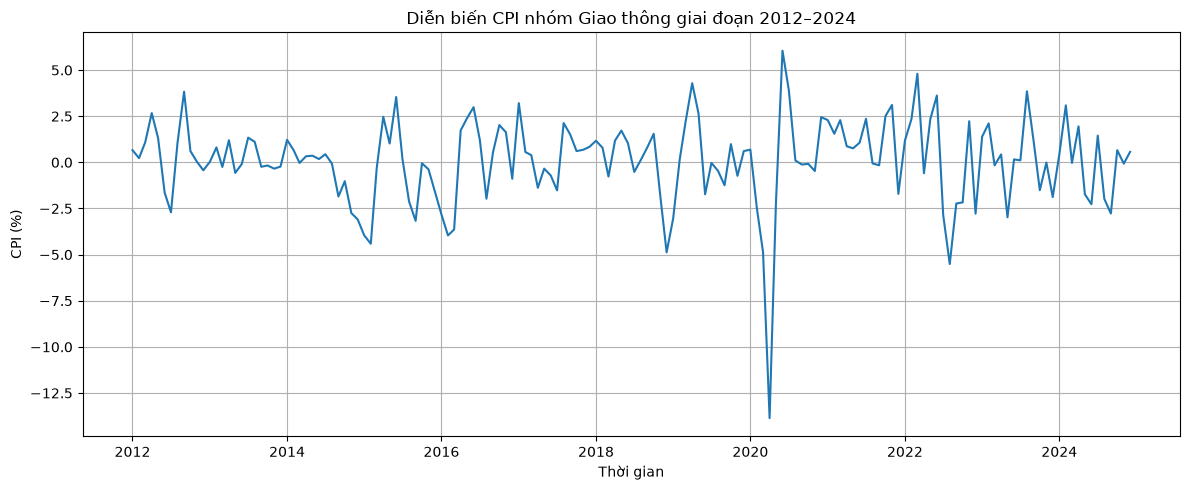

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df["MonthYear"].dt.to_timestamp(),
    df["CPI"]
)

plt.title("Diễn biến CPI nhóm Giao thông giai đoạn 2012–2024")
plt.xlabel("Thời gian")
plt.ylabel("CPI (%)")
plt.grid(True)
plt.tight_layout()

plt.show()